[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Laverde97/phd-data-science-ai/blob/main/semesters/semester-01/machine-learning/notebooks/class-notes/08-clase-2026-09-08-regresion-lineal.ipynb)

## MACHINE LEARNING: MODELO DE REGRESION

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

importando el conjunto de datos
https://cdtiueb.com.co/doctorado/salarios_experiencia_reg1.csv

In [ ]:
dataset=pd.read_csv('https://cdtiueb.com.co/doctorado/salarios_experiencia_reg1.csv')
#dataset= pd.read_csv('DATOS1.csv');
print(dataset)

    experiencia   salario
0           0.6   2000000
1           1.0   2100000
2           1.0   2400000
3           1.1   2100000
4           1.2   2200000
..          ...       ...
88          9.6  10500000
89          9.7   9500000
90          9.8  10500000
91          9.9  10500000
92         10.0  11000000

[93 rows x 2 columns]


In [ ]:
dataset

,experiencia,salario
0,0.6,2000000
1,1.0,2100000
2,1.0,2400000
3,1.1,2100000
4,1.2,2200000
...,...,...
88,9.6,10500000
89,9.7,9500000
90,9.8,10500000
91,9.9,10500000


In [ ]:
X=dataset.iloc[:,:-1].values # En X en mayuscula ya que es el set de los datos
print("============================================== \n data en X")
print(X)
y=dataset.iloc[:,-1].values
print("============================================== \n data en y")
print(y)

 data en X
[[ 0.6]
 [ 1. ]
 [ 1. ]
 [ 1.1]
 [ 1.2]
 [ 1.3]
 [ 1.4]
 [ 1.5]
 [ 1.6]
 [ 1.7]
 [ 1.8]
 [ 1.9]
 [ 2. ]
 [ 2.1]
 [ 2.2]
 [ 2.3]
 [ 2.4]
 [ 2.5]
 [ 2.6]
 [ 2.7]
 [ 2.8]
 [ 2.9]
 [ 3. ]
 [ 3.1]
 [ 3.2]
 [ 3.3]
 [ 3.4]
 [ 3.5]
 [ 3.6]
 [ 3.7]
 [ 3.8]
 [ 3.9]
 [ 4. ]
 [ 4.1]
 [ 4.2]
 [ 4.3]
 [ 4.4]
 [ 4.5]
 [ 4.6]
 [ 4.7]
 [ 4.8]
 [ 4.9]
 [ 5. ]
 [ 5.1]
 [ 5.2]
 [ 5.3]
 [ 5.4]
 [ 5.5]
 [ 5.6]
 [ 5.7]
 [ 5.8]
 [ 5.9]
 [ 6. ]
 [ 6.1]
 [ 6.2]
 [ 6.3]
 [ 6.4]
 [ 6.5]
 [ 6.6]
 [ 6.7]
 [ 6.8]
 [ 6.9]
 [ 7. ]
 [ 7.1]
 [ 7.2]
 [ 7.3]
 [ 7.4]
 [ 7.5]
 [ 7.6]
 [ 7.7]
 [ 7.8]
 [ 7.9]
 [ 8. ]
 [ 8.1]
 [ 8.2]
 [ 8.3]
 [ 8.4]
 [ 8.5]
 [ 8.6]
 [ 8.7]
 [ 8.8]
 [ 8.9]
 [ 9. ]
 [ 9.1]
 [ 9.2]
 [ 9.3]
 [ 9.4]
 [ 9.5]
 [ 9.6]
 [ 9.7]
 [ 9.8]
 [ 9.9]
 [10. ]]
 data en y
[ 2000000  2100000  2400000  2100000  2200000  2280000  2500000  2500000
  2550000  2900000  2760000  2855000  2950000  3000000  3000000  3235000
  3330000  3000000  3520000  3200000  3710000  3805000  3900000  4000000
  4000000  400

Separando los datos en conjunto de entrenamiento y conjunto de pruebas

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=0)

Ahora se muestra el conjunto de datos de entrenamiento

In [ ]:
X_train

array([[10. ],
       [ 3.4],
       [ 5. ],
       [ 3.2],
       [ 1.4],
       [ 4.9],
       [ 7.9],
       [ 8.1],
       [ 6.8],
       [ 8.4],
       [ 9. ],
       [ 9.3],
       [ 1.1],
       [ 8.8],
       [ 5.6],
       [ 3.5],
       [ 2.6],
       [ 6.1],
       [ 6.2],
       [ 9.4],
       [ 7. ],
       [ 8.9],
       [ 1.2],
       [ 2.3],
       [ 2.5],
       [ 4.8],
       [ 4.6],
       [ 1.3],
       [ 9.2],
       [ 8.3],
       [ 0.6],
       [ 4.2],
       [ 3.6],
       [ 5.8],
       [ 1.9],
       [ 4.3],
       [ 3.1],
       [ 6. ],
       [ 1.8],
       [ 3.9],
       [ 7.1],
       [ 6.5],
       [ 8.2],
       [ 1. ],
       [ 4. ],
       [ 8.7],
       [ 2.2],
       [ 9.6],
       [ 2.7],
       [ 3.7],
       [ 5.7],
       [ 9.8],
       [ 9.9],
       [ 7.7],
       [ 2.8],
       [ 9.5],
       [ 8. ],
       [ 3.3],
       [ 4.5],
       [ 5.4],
       [ 4.7],
       [ 7.3],
       [ 6.6],
       [ 2. ],
       [ 7.8],
       [ 4.4],
       [ 2

In [ ]:
y_train

array([11000000,  4280000,  5800000,  4000000,  2500000,  5705000,
        8555000,  8745000,  7510000,  9030000,  9600000,  9885000,
        2100000,  9410000,  6370000,  4375000,  3520000,  6845000,
        6940000,  9980000,  7700000,  9505000,  2200000,  3235000,
        3000000,  5610000,  5420000,  2280000,  9790000,  8935000,
        2000000,  5040000,  4470000,  6500000,  2855000,  5000000,
        4000000,  6500000,  2760000,  4755000,  7795000,  7225000,
        8840000,  2100000,  4850000,  9050000,  3000000, 10500000,
        3200000,  4565000,  6000000, 10500000, 10500000,  8365000,
        3710000, 10500000,  8650000,  4000000,  5325000,  6180000,
        5515000,  7985000,  7320000,  2950000,  8460000,  4500000,
        3805000,  9695000,  2900000,  9500000,  8175000,  7890000,
        6275000,  5990000])

In [ ]:
y_train

array([11000000,  4280000,  5800000,  4000000,  2500000,  5705000,
        8555000,  8745000,  7510000,  9030000,  9600000,  9885000,
        2100000,  9410000,  6370000,  4375000,  3520000,  6845000,
        6940000,  9980000,  7700000,  9505000,  2200000,  3235000,
        3000000,  5610000,  5420000,  2280000,  9790000,  8935000,
        2000000,  5040000,  4470000,  6500000,  2855000,  5000000,
        4000000,  6500000,  2760000,  4755000,  7795000,  7225000,
        8840000,  2100000,  4850000,  9050000,  3000000, 10500000,
        3200000,  4565000,  6000000, 10500000, 10500000,  8365000,
        3710000, 10500000,  8650000,  4000000,  5325000,  6180000,
        5515000,  7985000,  7320000,  2950000,  8460000,  4500000,
        3805000,  9695000,  2900000,  9500000,  8175000,  7890000,
        6275000,  5990000])

In [ ]:
y_test

array([2400000, 5000000, 7035000, 3330000, 3000000, 6500000, 7605000,
       6500000, 4945000, 9050000, 9050000, 2500000, 7130000, 8080000,
       5895000, 7415000, 2550000, 3900000, 8270000])

Vamos a utilizar el modelo de regresión lineal en Python

In [ ]:
from sklearn.linear_model import LinearRegression
regressor=LinearRegression();
regressor.fit(X_train,y_train);

Predecir el conjunto de prueba


In [ ]:
y_predict=regressor.predict(X_test);

Desplegamos la precisión y el de la salida de prueba

In [ ]:
y_test

array([2400000, 5000000, 7035000, 3330000, 3000000, 6500000, 7605000,
       6500000, 4945000, 9050000, 9050000, 2500000, 7130000, 8080000,
       5895000, 7415000, 2550000, 3900000, 8270000])

In [ ]:
y_predict

array([1958368.95028389, 4630072.91404902, 7015522.88169646,
       3294220.93216645, 3007966.93604876, 6633850.88687287,
       7588030.87393185, 6061342.89463749, 4916326.91016671,
       9114718.85322621, 9210136.85193211, 2435458.94381338,
       7110940.88040236, 8065120.86746134, 5870506.89722569,
       7397194.87652005, 2530876.94251927, 3866728.92440184,
       8255956.86487313])

Se grafican de entrenamiento Vs la regresión de los datos de entrenamiento

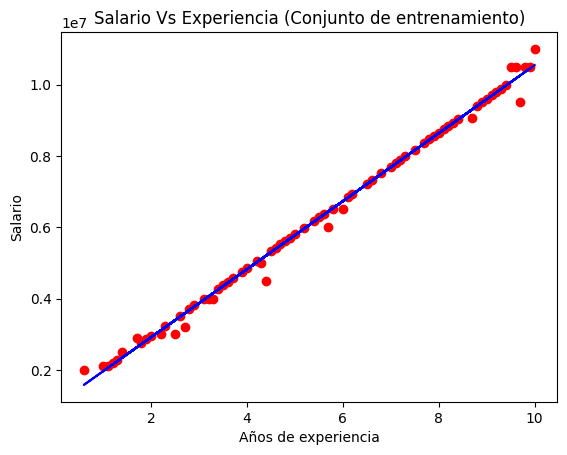

In [ ]:
plt.scatter(X_train,y_train,color='red')
plt.plot(X_train,regressor.predict(X_train),color='blue')
plt.title('Salario Vs Experiencia (Conjunto de entrenamiento)')
plt.xlabel('Años de experiencia')
plt.ylabel('Salario')
plt.show()

Se verifica si las salidas de prueba son acordes con el modelo

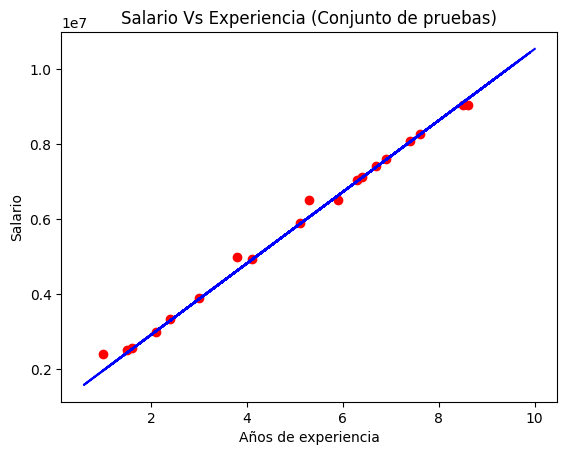

In [ ]:
plt.scatter(X_test,y_test,color='red')
plt.plot(X_train,regressor.predict(X_train),color='blue')
plt.title('Salario Vs Experiencia (Conjunto de pruebas)')
plt.xlabel('Años de experiencia')
plt.ylabel('Salario')
plt.show()

Se comparan las gráficas de prueba Vs predicción así:

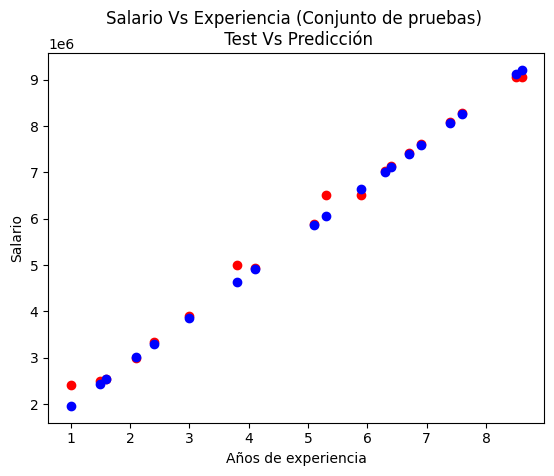

In [ ]:
plt.scatter(X_test,y_test,color='red')
plt.scatter(X_test,y_predict,color='blue')
plt.title('Salario Vs Experiencia (Conjunto de pruebas) \n Test Vs Predicción')
plt.xlabel('Años de experiencia')
plt.ylabel('Salario')
plt.show()


Se contiene la ecuación de la recta de regresión

In [ ]:
# Obtener coeficientes e intercepto
coeficientes = regressor.coef_
intercepto = regressor.intercept_
print('la ecuación es: -->  Y=', coeficientes,'*','años_de_experiencia', '+',intercepto);

la ecuación es: -->  Y= [954179.98705898] * años_de_experiencia + 1004188.9632249102


Ejemplo

In [ ]:
años_experiencia=float(input('Digiete los años de experiencia'));
Y= 954179.98705898* años_experiencia + 1004188.9632249102
print('El salario debe ser---> ', Y)

Digiete los años de experiencia8
El salario debe ser--->  8637628.85969675


In [ ]:
print('Matriz de correlación:')
print(dataset.corr())

Matriz de correlación:
             experiencia   salario
experiencia     1.000000  0.997411
salario         0.997411  1.000000
